# MP2 Parts 2–4 — Time series, gaps, themes, interpretation (gelkhoda)
Needs `gelkhoda_project_summary.csv`, `gelkhoda_gh_stats.csv`, `gelkhoda_gh_recent_commits.csv` from `gelkhoda.ipynb`.

In [1]:
NETID = 'gelkhoda'
STATUS_CUTOFF = '2025-04-01'   # README: inactive if no GH commit in 6 months before 2025-09-30
GH_TOKEN = ''                  # optional, only used by the issue/PR evidence cell

import re, time, requests
import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option('display.max_colwidth', 120)

df = pd.read_csv(f'{NETID}_project_summary.csv', sep=';', keep_default_na=False, dtype=str)
df.columns = ['project', 'commit', 'author', 'time', 'message']
df['time'] = df['time'].astype('int64')
df['Month'] = pd.to_datetime(df['time'], unit='s', utc=True).dt.strftime('%Y-%m')
gh = pd.read_csv(f'{NETID}_gh_stats.csv', sep=';', index_col=0)
recent = pd.read_csv(f'{NETID}_gh_recent_commits.csv', sep=';', keep_default_na=False, dtype=str)
projects = list(gh.index)
df.groupby('project').size()

project
almost-matching-exactly_dame-python-package      501
bsaul_inferference                               328
copasi_copasi-dependencies                       515
daohu527_dig-into-apollo                         425
gsi-cs-co_chart-fx                              3633
martin2250_opencncpilot                          253
sakov_enkf-c                                    1772
sfc-aqua_quisp                                  4409
stan-dev_rstanarm                               4146
usgs-astrogeology_isis3                        18318
dtype: int64

## Part 2 — Monthly time series + plots

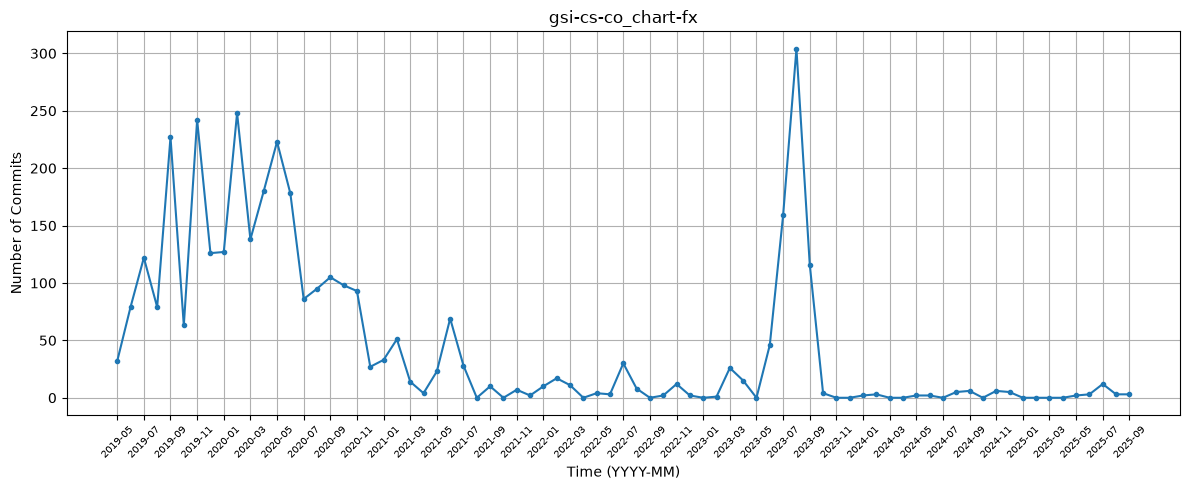

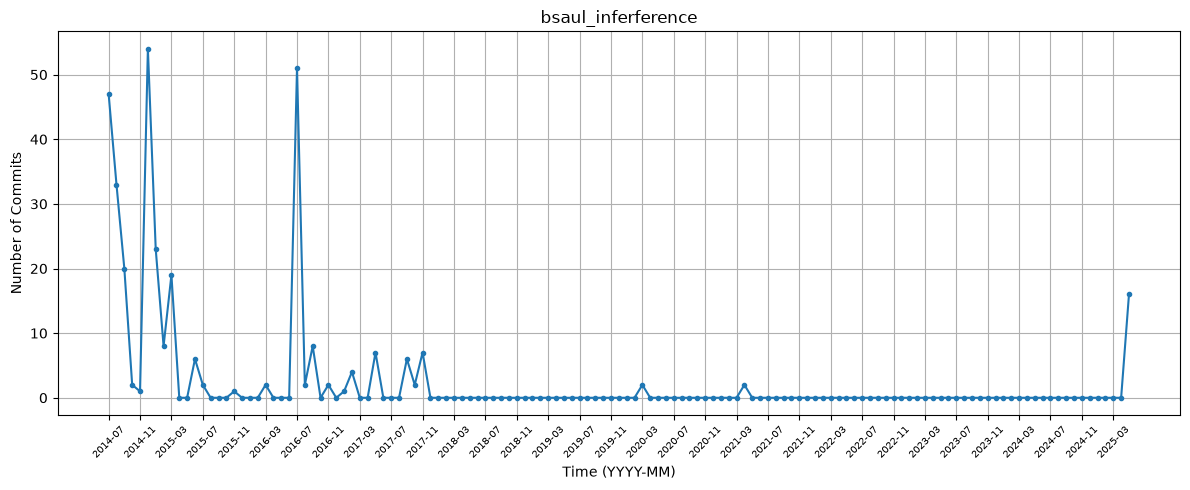

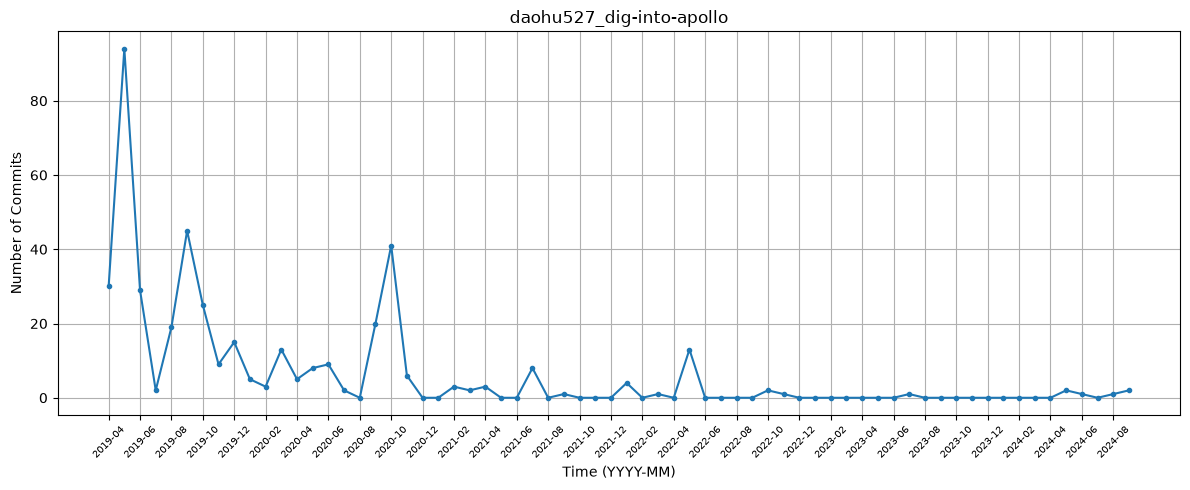

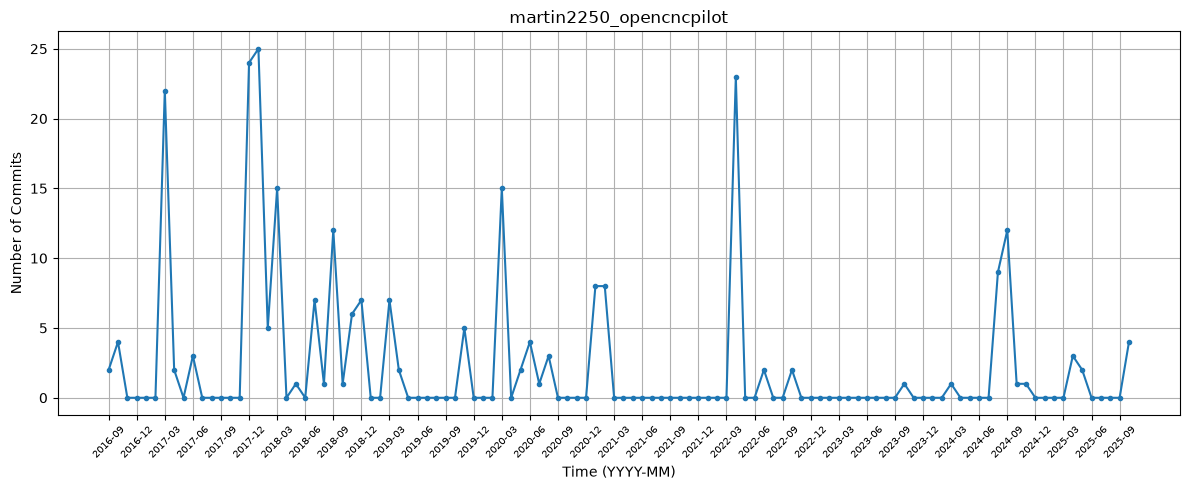

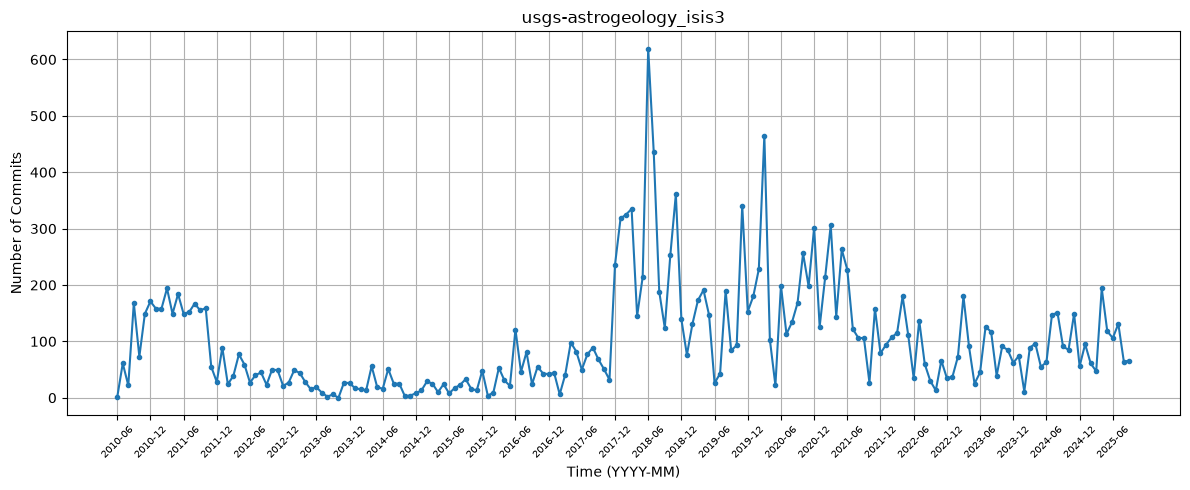

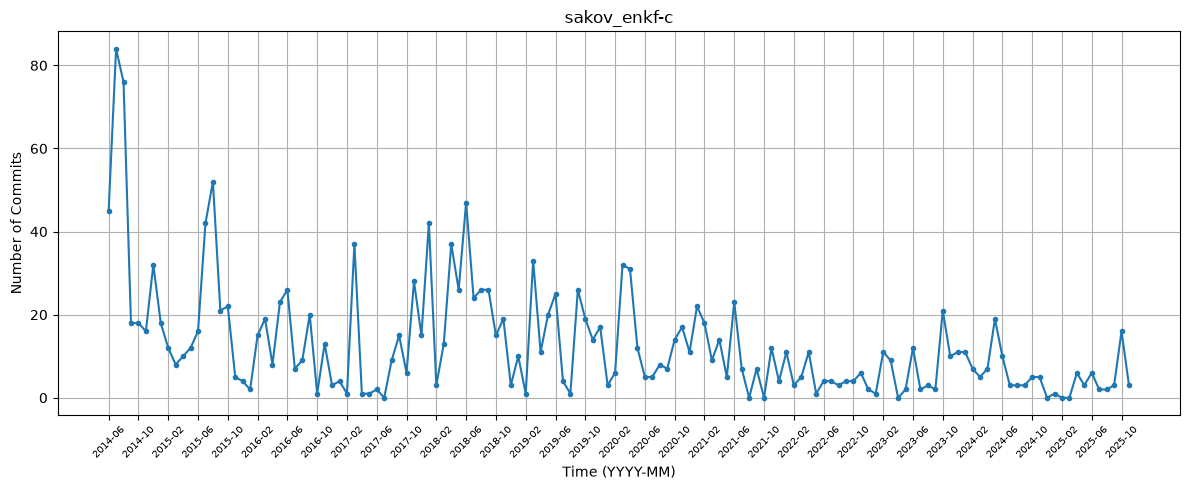

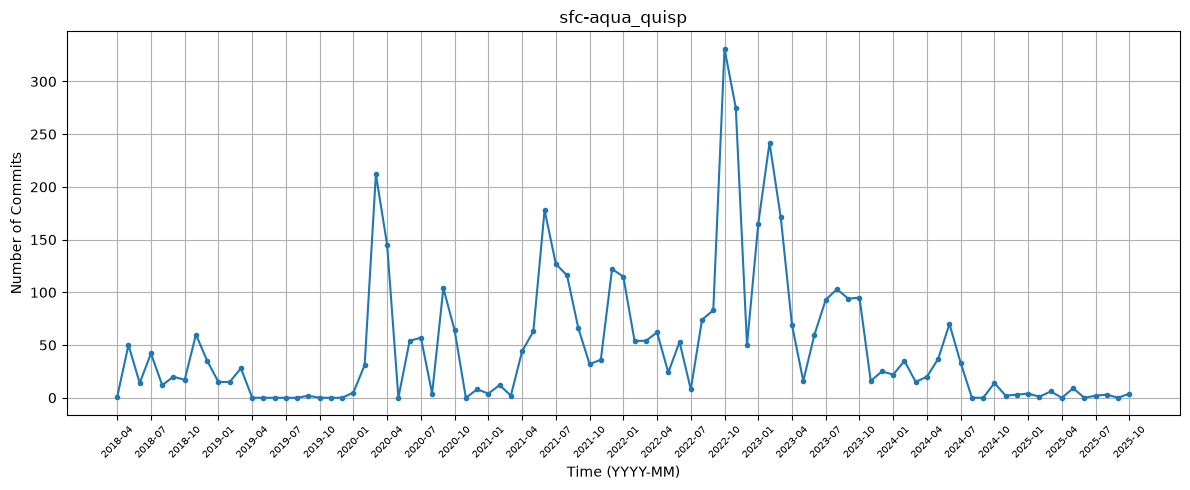

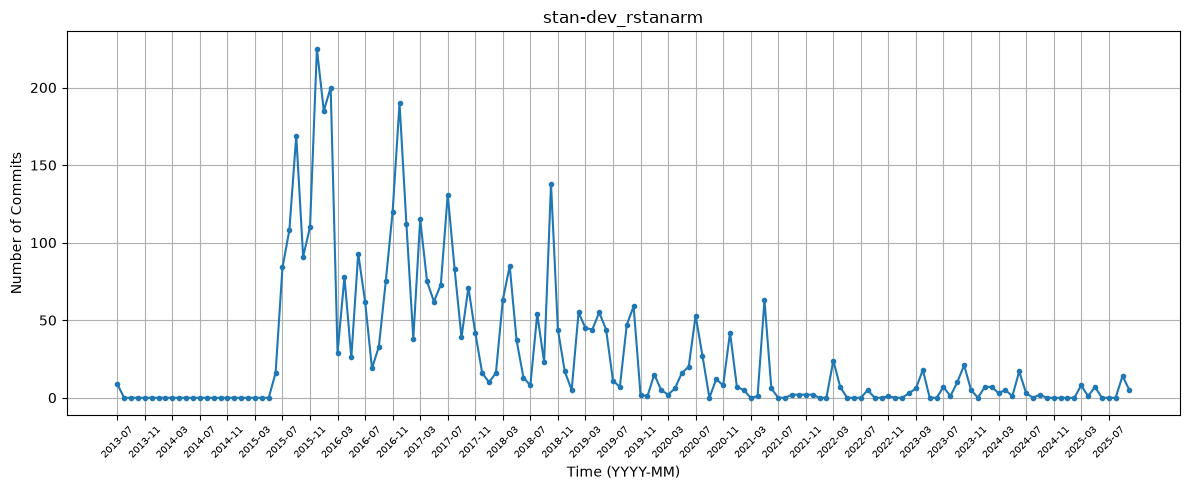

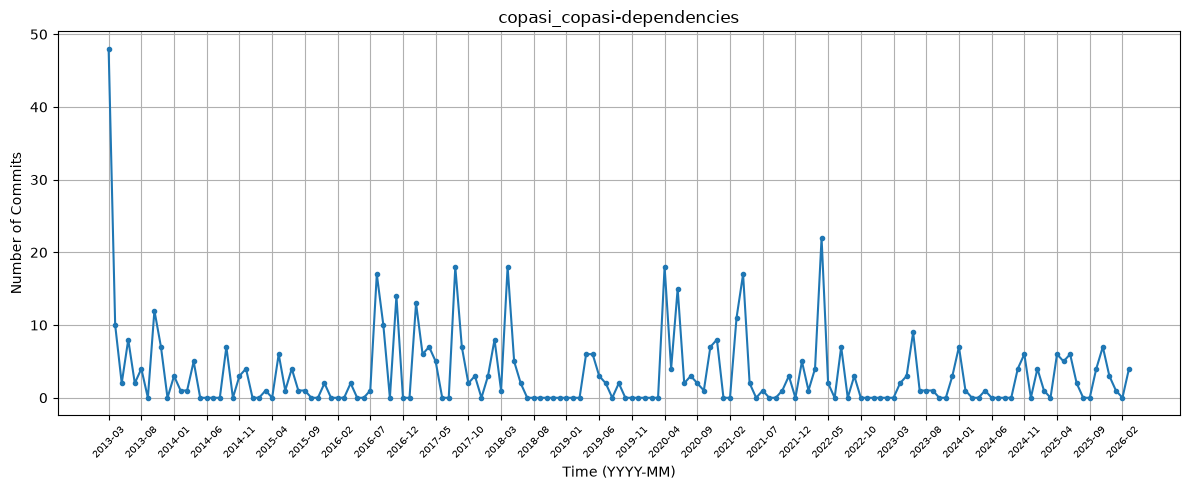

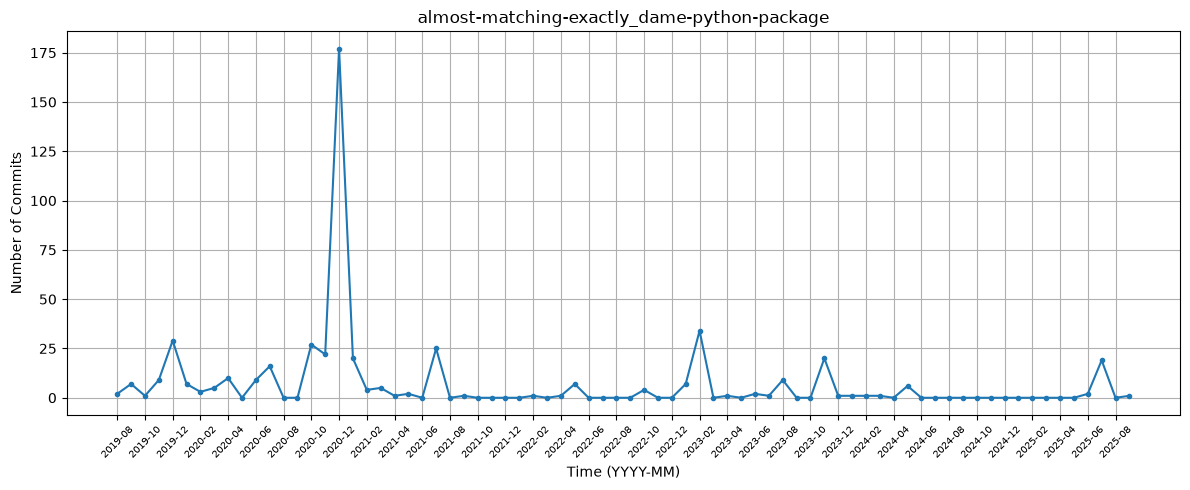

In [2]:
def monthly(p):
    d = df[df.project == p]
    idx = pd.period_range(d['Month'].min(), d['Month'].max(), freq='M').strftime('%Y-%m')
    s = d.groupby('Month').size().reindex(idx, fill_value=0)
    return pd.DataFrame({'Month': idx, '#Commits': s.values})

series = {}
for p in projects:
    ts = monthly(p); series[p] = ts
    ts.to_csv(f'{NETID}_commits_timeseries_{p}.csv', sep=';', index=False)
    plt.figure(figsize=(12, 5))
    plt.plot(ts['Month'], ts['#Commits'], marker='o', markersize=3, linestyle='-')
    plt.xlabel('Time (YYYY-MM)'); plt.ylabel('Number of Commits'); plt.title(p)
    plt.grid(True)
    step = max(1, len(ts) // 30)
    plt.xticks(range(0, len(ts), step), ts['Month'][::step], rotation=45, fontsize=7)
    plt.tight_layout()
    plt.savefig(f'{NETID}_timeseries_{p}.png', dpi=300)
    plt.show(); plt.close()

pd.concat([s.assign(project=p) for p, s in series.items()])[['project', 'Month', '#Commits']] \
  .to_csv(f'{NETID}_commits_timeseries_.csv', sep=';', index=False)

## Longest gap, number of gaps (≥3 zero months), activity pattern

In [3]:
def zero_runs(ts):
    runs, start = [], None
    for i, v in enumerate(ts['#Commits']):
        if v == 0 and start is None: start = i
        if v != 0 and start is not None: runs.append((start, i - 1)); start = None
    if start is not None: runs.append((start, len(ts) - 1))
    return runs

def pattern(ts):
    y = ts['#Commits'].values.astype(float)
    if len(y) < 6: return 'irregular'
    k = len(y) // 3
    a, b, c = y[:k].mean(), y[k:2*k].mean(), y[2*k:].mean()
    cv = y.std() / (y.mean() + 1e-9)
    # seasonality: autocorrelation at lag 12
    if len(y) >= 36:
        yc = y - y.mean(); ac12 = (yc[12:] * yc[:-12]).sum() / ((yc**2).sum() + 1e-9)
        if ac12 > 0.4: return 'cyclical'
    if b < 0.6 * min(a, c) and c > 0.6 * a: return 'U-shaped'
    if cv < 0.6: return 'steady'
    if c > 1.5 * a and c >= b: return 'rising'
    if c < 0.67 * a and c <= b: return 'declining'
    return 'irregular'

rows = []
for p in projects:
    ts = series[p]; runs = zero_runs(ts); d = df[df.project == p]
    r = {'project': p, 'ncommits': d['commit'].nunique(), 'nauthors': d['author'].nunique(),
         'from': d['time'].min(), 'to': d['time'].max(),
         'nstars': gh.loc[p, 'nstars'], 'nforks': gh.loc[p, 'nforks'],
         'lastGHCommitDate': gh.loc[p, 'lastGHCommitDate']}
    if runs:
        s, e = max(runs, key=lambda t: (t[1] - t[0], -t[0]))   # longest; earliest on ties
        r.update({'LongestGapStart (YYYY-MM)': ts['Month'][s], 'LongestGapEnd (YYYY-MM)': ts['Month'][e],
                  'LongestGapLength (months)': e - s + 1,
                  'NumCommitsAfterLastGap': int(ts['#Commits'][e+1:].sum())})
    else:
        r.update({'LongestGapStart (YYYY-MM)': 'N/A', 'LongestGapEnd (YYYY-MM)': 'N/A',
                  'LongestGapLength (months)': 0, 'NumCommitsAfterLastGap': r['ncommits']})
    r['ActivityPattern'] = pattern(ts)
    r['NumberOfGapsInTimeline'] = sum(1 for s, e in runs if e - s + 1 >= 3)
    rows.append(r)
stats = pd.DataFrame(rows).set_index('project')
stats

,ncommits,nauthors,from,to,nstars,nforks,lastGHCommitDate,LongestGapStart (YYYY-MM),LongestGapEnd (YYYY-MM),LongestGapLength (months),NumCommitsAfterLastGap,ActivityPattern,NumberOfGapsInTimeline
project,,,,,,,,,,,,,
gsi-cs-co_chart-fx,3633,53,1557246279,1758770120,613,110,2026-03-13,2025-01,2025-04,4,23,irregular,1
bsaul_inferference,328,16,1404407958,1747234885,6,2,2025-05-14,2021-05,2025-04,48,16,irregular,7
daohu527_dig-into-apollo,425,7,1554864597,1725447268,2457,714,2026-02-03,2023-08,2024-04,9,6,declining,4
martin2250_opencncpilot,253,15,1474378401,1759704094,427,124,2025-04-28,2021-03,2022-03,13,61,declining,11
usgs-astrogeology_isis3,18318,200,1276037385,1759270719,245,182,2026-09-24,2013-10,2013-10,1,15223,irregular,0
sakov_enkf-c,1772,7,1403133737,1762472241,47,25,2026-09-22,2025-02,2025-03,2,41,declining,0
sfc-aqua_quisp,4409,87,1524058198,1761562984,109,43,2026-03-31,2019-04,2019-08,5,4100,irregular,2
stan-dev_rstanarm,4146,64,1373994672,1761779325,401,136,2026-09-21,2013-08,2015-05,22,4137,declining,4
copasi_copasi-dependencies,515,16,1362398954,1773320863,7,3,2026-09-16,2018-07,2019-03,9,240,declining,6


In [4]:
PATTERN_OVERRIDE = {
    'gsi-cs-co_chart-fx': 'irregular',
    'bsaul_inferference': 'declining',
    'daohu527_dig-into-apollo': 'declining',
    'martin2250_opencncpilot': 'irregular',
    'usgs-astrogeology_isis3': 'steady',
    'sakov_enkf-c': 'declining',
    'sfc-aqua_quisp': 'irregular',
    'stan-dev_rstanarm': 'declining',
    'copasi_copasi-dependencies': 'steady',
    'almost-matching-exactly_dame-python-package': 'declining',
}
for p, v in PATTERN_OVERRIDE.items(): stats.loc[p, 'ActivityPattern'] = v
stats[['ActivityPattern', 'NumberOfGapsInTimeline', 'LongestGapLength (months)']]

,ActivityPattern,NumberOfGapsInTimeline,LongestGapLength (months)
project,,,
gsi-cs-co_chart-fx,irregular,1,4
bsaul_inferference,declining,7,48
daohu527_dig-into-apollo,declining,4,9
martin2250_opencncpilot,irregular,11,13
usgs-astrogeology_isis3,steady,0,1
sakov_enkf-c,declining,0,2
sfc-aqua_quisp,irregular,2,5
stan-dev_rstanarm,declining,4,22
copasi_copasi-dependencies,steady,6,9


## Interpretation
Patterns were assigned by reading each plot together with yearly commit totals. Gap counts are runs of at least three consecutive zero-commit months.

- **gsi-cs-co_chart-fx**: **irregular**. Large bursts in 2019–2020 (≈970 and ≈1,600 commits/yr), a drop in 2021–2022, a second spike in 2023 (≈670), then low activity, so there is no single trend. **1 gap** of ≥3 months.
- **bsaul_inferference**: **declining**. Most work happened in 2014–2017 around the v1.0.0/JSS publication, followed by near-zero activity and a one-day burst in May 2025. **7 gaps**.
- **daohu527_dig-into-apollo**: **declining**. Heavy activity in 2019 (268) and 2020 (112), then only a handful of commits per year. **4 gaps**.
- **martin2250_opencncpilot**: **irregular**. Small, bursty activity driven by occasional pull requests, with no consistent direction. **11 gaps**.
- **usgs-astrogeology_isis3**: **steady**. Hundreds to thousands of commits every year since 2010 (peak ≈3,450 in 2018). The only zero month is Oct 2013. **0 gaps**.
- **sakov_enkf-c**: **declining**. A regular single-maintainer release cadence, but yearly volume falls from ≈290 (2014) to ≈40–80 (2023–2025). **0 gaps**.
- **sfc-aqua_quisp**: **irregular**. Thesis-driven work in 2018–2019, then strong growth to ≈1,150–1,180/yr in 2022–2023 and a sharp drop after 2024. **2 gaps**.
- **stan-dev_rstanarm**: **declining**. A 2013 prototype, a gap, then a peak in 2016 (≈1,110) and a steady decline to ≈35–70/yr. **4 gaps**.
- **copasi_copasi-dependencies**: **steady**. Low but persistent activity (≈20–90/yr) every year since 2013, tied to dependency upgrades. **6 gaps**.
- **almost-matching-exactly_dame-python-package**: **declining**. A peak in 2020 (276), then small maintenance bursts. **3 gaps**.

In [5]:
for p, r in stats.iterrows():
    ts = series[p]
    peak = ts.loc[ts['#Commits'].idxmax()]
    gap = (f"longest gap {r['LongestGapStart (YYYY-MM)']}→{r['LongestGapEnd (YYYY-MM)']} ({r['LongestGapLength (months)']} mo)"
           if r['LongestGapLength (months)'] else 'no zero-commit months')
    print(f"- **{p}**: {r['ActivityPattern']}; {ts['Month'].iloc[0]}→{ts['Month'].iloc[-1]}, "
          f"peak {peak['#Commits']} commits in {peak['Month']}; {gap}; "
          f"{r['NumberOfGapsInTimeline']} gap(s) of ≥3 months.")

- **gsi-cs-co_chart-fx**: irregular; 2019-05→2025-09, peak 304 commits in 2023-08; longest gap 2025-01→2025-04 (4 mo); 1 gap(s) of ≥3 months.
- **bsaul_inferference**: declining; 2014-07→2025-05, peak 54 commits in 2014-12; longest gap 2021-05→2025-04 (48 mo); 7 gap(s) of ≥3 months.
- **daohu527_dig-into-apollo**: declining; 2019-04→2024-09, peak 94 commits in 2019-05; longest gap 2023-08→2024-04 (9 mo); 4 gap(s) of ≥3 months.
- **martin2250_opencncpilot**: irregular; 2016-09→2025-10, peak 25 commits in 2018-01; longest gap 2021-03→2022-03 (13 mo); 11 gap(s) of ≥3 months.
- **usgs-astrogeology_isis3**: steady; 2010-06→2025-09, peak 619 commits in 2018-06; longest gap 2013-10→2013-10 (1 mo); 0 gap(s) of ≥3 months.
- **sakov_enkf-c**: declining; 2014-06→2025-11, peak 84 commits in 2014-07; longest gap 2025-02→2025-03 (2 mo); 0 gap(s) of ≥3 months.
- **sfc-aqua_quisp**: irregular; 2018-04→2025-10, peak 331 commits in 2022-10; longest gap 2019-04→2019-08 (5 mo); 2 gap(s) of ≥3 months.
- **

## Part 3.1 — Commits before/after the longest gap + themes

In [6]:
THEMES = [
 ('Automated bot contributions', r'\[bot\]|dependabot|renovate|pre-commit-ci|github-actions|auto[- ]?format|autopep8|\bci skip\b'),
 ('Security patches',            r'secur|vulnerab|\bcve\b|exploit|sanitiz'),
 ('Release',                     r'\brelease|\bbump(ed)? version|\bversion \d|\bv?\d+\.\d+(\.\d+)?\b.*(release|tag)|\bprepare .*release|changelog|\bnews\b|\bcran\b'),
 ('Dependency updates',          r'depend|\bbump\b|upgrade|requirements|\bdeps?\b|submodule|update .*(library|lib|package|version)|third[- ]?party'),
 ('Bug fixes',                   r'\bfix|\bbug|\bissue|\berror|crash|\bpatch|correct|resolve|typo|workaround|broken|\bfail'),
 ('Documentation updates',       r'\bdoc|readme|comment|\bmanual|tutorial|vignette|\bwiki|\.md\b|example|guide|documentation'),
 ('Feature development',         r'\badd|\bnew\b|implement|feature|support|introduc|\benable|\bcreate|refactor|improv|enhanc|extend|\ballow'),
]
def theme(msg, author=''):
    text = f'{author} {msg}'.lower()
    for name, pat in THEMES:
        if name == 'Automated bot contributions':
            if re.search(pat, text): return name
        elif re.search(pat, msg.lower()): return name
    if msg.lower().startswith('merge'): return 'Other'
    return 'Other'

def top2(sub):
    if len(sub) == 0: return 'N/A'
    vc = pd.Series([theme(m, a) for m, a in zip(sub['message'], sub['author'])]).value_counts()
    return ':'.join(vc.index[:2]) if len(vc) > 1 else vc.index[0]

gap_rows = []
stats['BeforeThemes'] = 'N/A'; stats['AfterThemes'] = 'N/A'
for p, r in stats.iterrows():
    if not r['LongestGapLength (months)']: continue
    d = df[df.project == p].sort_values('time')
    pre = d[d['Month'] < r['LongestGapStart (YYYY-MM)']].tail(10)
    post = d[d['Month'] > r['LongestGapEnd (YYYY-MM)']].head(10)
    for tag, sub in (('pre', pre), ('post', post)):
        gap_rows.append(sub.assign(prepost=tag)[['prepost', 'project', 'commit', 'author', 'time', 'message']])
    stats.loc[p, 'BeforeThemes'] = top2(pre); stats.loc[p, 'AfterThemes'] = top2(post)

gap = pd.concat(gap_rows, ignore_index=True)
gap['theme'] = [theme(m, a) for m, a in zip(gap['message'], gap['author'])]
gap.drop(columns='theme').to_csv(f'{NETID}_project_gap_commits.csv', sep=';', index=False)
gap[['prepost', 'project', 'theme', 'message']]   # READ THESE and fix themes by hand if the keyword rules misfire

,prepost,project,theme,message
0,pre,gsi-cs-co_chart-fx,Other,AbstractRendererXY: Update axesList of AbstractRenderer when changed (#677)\n
1,pre,gsi-cs-co_chart-fx,Bug fixes,Fix endless update loop in the presence of empty DataSet (#674)\n\n
2,pre,gsi-cs-co_chart-fx,Feature development,Make NumberFormatterImpl work with UTF8 and allow optional exponential separator\n
3,pre,gsi-cs-co_chart-fx,Other,Make NumberFormatterImpl#fromString work if whitespace is used as exponential separator\n
4,pre,gsi-cs-co_chart-fx,Feature development,Improve axis label in case of empty name or unit\n\n- Remove leading white space when a unit was present but no axis...
...,...,...,...,...
190,post,almost-matching-exactly_dame-python-package,Feature development,remove new python version\n\nnot sure why travis still not running\n
191,post,almost-matching-exactly_dame-python-package,Other,change numpy to packaging\n\nreally unsure why travis won't run\n
192,post,almost-matching-exactly_dame-python-package,Bug fixes,Update .travis.yml\n\nanother attempt to fix travis setting\n
193,post,almost-matching-exactly_dame-python-package,Other,Update .travis.yml\n\nyet another attempt\n


In [7]:
THEME_OVERRIDE = {  # assigned by reading the pre/post commit messages above
    'gsi-cs-co_chart-fx': ('Bug fixes:Other', 'Bug fixes:Other'),
    'bsaul_inferference': ('Release:Documentation updates', 'Other:Automated bot contributions'),
    'daohu527_dig-into-apollo': ('Documentation updates:Other', 'Documentation updates:Feature development'),
    'martin2250_opencncpilot': ('Other:Release', 'Feature development:Bug fixes'),
    'usgs-astrogeology_isis3': ('Bug fixes:Documentation updates', 'Bug fixes:Other'),
    'sakov_enkf-c': ('Release:Documentation updates', 'Release:Documentation updates'),
    'sfc-aqua_quisp': ('Feature development:Other', 'Documentation updates:Other'),
    'stan-dev_rstanarm': ('Feature development:Bug fixes', 'Feature development:Documentation updates'),
    'copasi_copasi-dependencies': ('Dependency updates:Bug fixes', 'Dependency updates:Documentation updates'),
    'almost-matching-exactly_dame-python-package': ('Other:Automated bot contributions', 'Bug fixes:Other'),
}
for p, (b, a) in THEME_OVERRIDE.items(): stats.loc[p, ['BeforeThemes', 'AfterThemes']] = [b, a]
stats[['BeforeThemes', 'AfterThemes']]

,BeforeThemes,AfterThemes
project,,
gsi-cs-co_chart-fx,Bug fixes:Other,Bug fixes:Other
bsaul_inferference,Release:Documentation updates,Other:Automated bot contributions
daohu527_dig-into-apollo,Documentation updates:Other,Documentation updates:Feature development
martin2250_opencncpilot,Other:Release,Feature development:Bug fixes
usgs-astrogeology_isis3,Bug fixes:Documentation updates,Bug fixes:Other
sakov_enkf-c,Release:Documentation updates,Release:Documentation updates
sfc-aqua_quisp,Feature development:Other,Documentation updates:Other
stan-dev_rstanarm,Feature development:Bug fixes,Feature development:Documentation updates
copasi_copasi-dependencies,Dependency updates:Bug fixes,Dependency updates:Documentation updates


## Part 3.2 — Evidence around the gap (GitHub issues / PRs)

In [8]:
S = requests.Session(); S.headers['Accept'] = 'application/vnd.github+json'
if GH_TOKEN: S.headers['Authorization'] = f'Bearer {GH_TOKEN}'

def around_gap(p, r, months=3):
    full = gh.loc[p, 'gh_repo']
    s = (pd.Period(r['LongestGapStart (YYYY-MM)']) - months).start_time.strftime('%Y-%m-%d')
    e = (pd.Period(r['LongestGapEnd (YYYY-MM)']) + months).end_time.strftime('%Y-%m-%d')
    q = f'repo:{full} created:{s}..{e}'
    res = S.get('https://api.github.com/search/issues', params={'q': q, 'per_page': 30, 'sort': 'created', 'order': 'asc'})
    time.sleep(7 if not GH_TOKEN else 2.5)   # search API rate limit
    if res.status_code != 200: return f'  (search failed: {res.status_code})'
    items = res.json().get('items', [])
    return '\n'.join(f"  {i['created_at'][:10]} {'PR' if 'pull_request' in i else 'Issue'} #{i['number']} [{i['state']}] {i['title']}"
                     f"  ({i['user']['login']}, {i['comments']} comments)" for i in items) or '  (none)'

for p, r in stats.iterrows():
    if not r['LongestGapLength (months)']: continue
    print(f"\n=== {p}  gap {r['LongestGapStart (YYYY-MM)']}..{r['LongestGapEnd (YYYY-MM)']}")
    print(around_gap(p, r))


=== gsi-cs-co_chart-fx  gap 2025-01..2025-04


  2024-11-20 Issue #677 [closed] Plugins like DataPointTooltip are not working at all if axes were only added to the chart  (dedeibel, 0 comments)
  2024-11-20 PR #678 [closed] BP: AbstractRendererXY: Update axesList of AbstractRenderer when changed (#677)  (dedeibel, 2 comments)
  2024-11-20 Issue #679 [open] Plugin node rendering is broken when a data set is dynamically added  (dedeibel, 0 comments)
  2024-12-06 Issue #680 [open] Feature Request: add ID to X/YValueIndicator, X/YRangeIndicator  (wolfig, 1 comments)
  2024-12-06 PR #681 [open] Feature/axis name generation handle missing info  (dedeibel, 1 comments)
  2024-12-06 PR #682 [open] Feature/number formatter with optional exponential separator  (dedeibel, 1 comments)
  2024-12-12 PR #683 [closed] AbstractValueIndicator: prevent label editing when setEditable(false)  (dedeibel, 1 comments)
  2024-12-13 Issue #684 [open] Bug or feature? Combining ErrorDataSetRenderer and XYChart  (wolfig, 1 comments)
  2024-12-13 Issue #685 [clo

  (none)

=== daohu527_dig-into-apollo  gap 2023-08..2024-04


  2023-05-30 Issue #51 [open] 回答cyber笔记中的疑问  (DieYoungWsn, 0 comments)
  2023-07-15 Issue #52 [open] 怎么没有apollo.sh  (Sirius-1110, 2 comments)
  2023-07-26 PR #53 [closed] 111  (Handy-xing, 0 comments)
  2024-05-01 PR #56 [closed] R7.0.0  (daohu527, 0 comments)
  2024-05-01 Issue #57 [open] Complete planning scenario code analysis  (daohu527, 0 comments)
  2024-06-01 PR #58 [closed] ANP-106202 zidingyi  (PG-Wang, 1 comments)

=== martin2250_opencncpilot  gap 2021-03..2022-03


  2020-12-09 Issue #150 [open] Big amount of ram over 500.000 line  (Elvis999IT, 3 comments)
  2021-01-26 PR #151 [closed] Added support for Ethernet connection  (gonzalocargut, 5 comments)
  2021-02-15 Issue #152 [open]  x y autolevel offset  (roneylf, 5 comments)
  2021-02-28 Issue #153 [closed] Добавление новых функций  (max-radio, 3 comments)
  2021-03-01 Issue #154 [closed] Compiled Zip file for release 1.5.11 runs as 1.5.10   (Win-doze, 1 comments)
  2021-03-03 Issue #155 [closed] Opencncpilot on winxp  (PinoS56, 1 comments)
  2021-03-15 Issue #156 [closed] bdring port crash  (jschoch, 3 comments)
  2021-04-21 Issue #157 [closed] Can support for grbl-Mega-5X be added?  (viewsat, 4 comments)
  2021-07-16 Issue #158 [open] Height map going too deep or too shallow  (ghost, 2 comments)
  2021-09-17 Issue #159 [open] Z-Axis driven to top limit when Heightmap run  (charlt0n, 5 comments)
  2022-04-12 Issue #160 [closed] when click "Probe and set zero" Z-axis motor vibrates and does not 

...

  (none)

=== sfc-aqua_quisp  gap 2019-04..2019-08


  (none)

=== stan-dev_rstanarm  gap 2013-08..2015-05


  2015-06-30 Issue #1 [closed] add support for binomial models  (jgabry, 2 comments)
  2015-06-30 Issue #2 [closed] add support for ordinal and multinomial logit models  (jgabry, 1 comments)
  2015-07-01 PR #3 [closed] merge jsg branch into master  (jgabry, 0 comments)
  2015-07-01 Issue #4 [closed] add predict method  (jgabry, 19 comments)
  2015-07-04 PR #5 [closed] Support moels withouth intercept  (jgabry, 0 comments)
  2015-07-05 Issue #6 [closed] return "clean" stan code to user   (jgabry, 0 comments)
  2015-07-06 PR #7 [closed] Pointwise log likelihood  (jgabry, 0 comments)
  2015-07-06 PR #8 [closed] Pointwise log likelihood  (jgabry, 0 comments)
  2015-07-09 Issue #9 [closed] non-MCMC options  (bgoodri, 0 comments)
  2015-07-14 Issue #10 [closed] allow binomial #trials to be specified using weights argument  (jgabry, 0 comments)
  2015-07-23 Issue #11 [closed] have option to draw from the prior of any model  (bgoodri, 5 comments)
  2015-07-23 Issue #12 [open] add IRT model(s) 

  2019-04-03 PR #3 [closed] fix typo for crossguid  (jonasfoe, 0 comments)
  2019-04-04 Issue #4 [closed] Building crossguid on macOS failes  (jonasfoe, 2 comments)
  2019-05-02 PR #5 [closed] - add crossguid and zipper dependencies to createLinux-qt5.sh  (lkeegan, 0 comments)

=== almost-matching-exactly_dame-python-package  gap 2024-06..2025-05


  2024-03-19 PR #71 [open] Bump nokogiri from 1.14.3 to 1.16.3 in /docs  (dependabot[bot], 0 comments)
  2024-04-08 Issue #72 [open] Populate root of each documentation section?   (nickeubank, 0 comments)
  2024-05-29 Issue #73 [open] Webpage updates needed  (nehargupta, 2 comments)
  2024-08-01 Issue #74 [closed] Error? "Matching stopped while attempting iteration 1 due to the PE fraction early stopping criterion."  (cignals24, 1 comments)
  2025-06-17 Issue #75 [open] Chained assignment in DAME  (nickeubank, 1 comments)
  2025-06-17 PR #76 [closed] fixes chained assignment that will break with Copy-on-Write transition  (nickeubank, 5 comments)


In [9]:
# Who recovered? compare post-gap authors with everyone active before the gap
def email(a): m = re.search(r'<([^>]+)>', a); return (m.group(1) if m else a).lower()
def name(a): return a.split('<')[0].strip().lower()
stats['HasRecovered'] = 'N/A'; stats['WhoRecovered'] = 'N/A'
for p, r in stats.iterrows():
    if not r['LongestGapLength (months)']: continue
    d = df[df.project == p]
    before = d[d['Month'] < r['LongestGapStart (YYYY-MM)']]
    after = d[d['Month'] > r['LongestGapEnd (YYYY-MM)']]
    if len(after) == 0:
        stats.loc[p, ['HasRecovered', 'WhoRecovered']] = ['No', 'N/A (no commits after gap)']; continue
    old = set(before['author'].map(email)) | set(before['author'].map(name))
    auth = after['author'].value_counts()
    ret = [a for a in auth.index if email(a) in old or name(a) in old]
    new = [a for a in auth.index if a not in ret]
    ret_c, new_c = auth[ret].sum(), auth[new].sum()
    who = ('Same contributors' if new_c == 0 else 'New contributors' if ret_c == 0 else 'Mix of returning and new contributors')
    top = ', '.join(name(a) for a in auth.index[:3])
    stats.loc[p, 'HasRecovered'] = 'Yes'
    stats.loc[p, 'WhoRecovered'] = f'{who} ({ret_c} commits by returning, {new_c} by new; top: {top})'
stats[['HasRecovered', 'WhoRecovered']]

,HasRecovered,WhoRecovered
project,,
gsi-cs-co_chart-fx,Yes,"Mix of returning and new contributors (10 commits by returning, 13 by new; top: lc, florian enner, lacgit)"
bsaul_inferference,Yes,"Same contributors (16 commits by returning, 0 by new; top: bradley saul, bsaul)"
daohu527_dig-into-apollo,Yes,"Mix of returning and new contributors (4 commits by returning, 2 by new; top: zero, daohu527, pg-wang)"
martin2250_opencncpilot,Yes,"Mix of returning and new contributors (12 commits by returning, 49 by new; top: deharro, paciente8159, martin pitter..."
usgs-astrogeology_isis3,Yes,"Mix of returning and new contributors (1855 commits by returning, 13368 by new; top: jesse mapel, acpaquette, kristin)"
sakov_enkf-c,Yes,"Same contributors (41 commits by returning, 0 by new; top: sakov, pavel sakov)"
sfc-aqua_quisp,Yes,"Mix of returning and new contributors (3 commits by returning, 4097 by new; top: zigen, chibikuri, soon)"
stan-dev_rstanarm,Yes,"Mix of returning and new contributors (1232 commits by returning, 2905 by new; top: jgabry, ben goodrich, sam brille..."
copasi_copasi-dependencies,Yes,"Mix of returning and new contributors (234 commits by returning, 6 by new; top: frank t. bergmann, stefan hoops, fra..."


In [10]:
# Current status + RecentThemes (last 10 commits on GitHub)
stats['Currentstatus'] = ['Active' if str(gh.loc[p, 'lastGHCommitDate']) >= STATUS_CUTOFF else 'Inactive' for p in stats.index]
stats['RecentThemes'] = [top2(recent[recent.project_wocid == p].rename(columns={'commit message': 'message'})) for p in stats.index]
rc = recent.copy(); rc['theme'] = [theme(m, a) for m, a in zip(rc['commit message'], rc['author'])]
display(stats[['lastGHCommitDate', 'Currentstatus', 'RecentThemes']])
rc[['project_wocid', 'date', 'theme', 'commit message']]

,lastGHCommitDate,Currentstatus,RecentThemes
project,,,
gsi-cs-co_chart-fx,2026-03-13,Active,Bug fixes:Feature development
bsaul_inferference,2025-05-14,Active,Other:Feature development
daohu527_dig-into-apollo,2026-02-03,Active,Documentation updates:Bug fixes
martin2250_opencncpilot,2025-04-28,Active,Bug fixes:Documentation updates
usgs-astrogeology_isis3,2026-09-24,Active,Release:Bug fixes
sakov_enkf-c,2026-09-22,Active,Other
sfc-aqua_quisp,2026-03-31,Active,Bug fixes:Other
stan-dev_rstanarm,2026-09-21,Active,Bug fixes:Other
copasi_copasi-dependencies,2026-09-16,Active,Other:Dependency updates


,project_wocid,date,theme,commit message
0,gsi-cs-co_chart-fx,2026-03-13T22:11:52Z,Release,meta: update Zenodo metadata with full contributor list and DOI badge (#711)\n\n* meta: update Zenodo metadata with ...
1,gsi-cs-co_chart-fx,2026-03-13T16:43:47Z,Feature development,meta: add .zenodo.json and CITATION.cff with verified ORCIDs\n\nSigned-off-by: Ralph J. Steinhagen <r.steinhagen@gsi...
2,gsi-cs-co_chart-fx,2025-12-10T08:37:18Z,Bug fixes,Fix minor tick count for log axis\n\nFixes #694
3,gsi-cs-co_chart-fx,2025-08-12T16:34:49Z,Feature development,BP: EditAxis plugin: prevent OOM when adding and removing axes dynamically
4,gsi-cs-co_chart-fx,2025-07-26T17:45:08Z,Bug fixes,fixed bar rendering issue #695
...,...,...,...,...
95,almost-matching-exactly_dame-python-package,2023-12-16T22:55:54Z,Bug fixes,"Update data_cleaning.py\n\nSo if no holdout data provided, uses the entire input data. AND it shouldn't error if you..."
96,almost-matching-exactly_dame-python-package,2023-11-22T21:31:32Z,Feature development,Add faraday-retry to the gemfile\n\nand corresponding lock file which should do something
97,almost-matching-exactly_dame-python-package,2023-11-22T21:28:03Z,Other,Update Gemfile.lock\n\nReally not sure if I'm helping here
98,almost-matching-exactly_dame-python-package,2023-11-22T21:16:38Z,Automated bot contributions,Bump tzinfo from 1.2.7 to 1.2.10 in /docs (#52)\n\nBumps [tzinfo](https://github.com/tzinfo/tzinfo) from 1.2.7 to 1....


## Part 3.2 / 4 — Hypotheses and notes (FILL IN from the evidence above)
Base each answer on commit messages first, then issues/PRs/README. Cite concrete facts (dates, commit messages, issue numbers).

In [11]:
MANUAL = {
 "gsi-cs-co_chart-fx": {
  "RecentThemes": "Bug fixes:Other",
  "HypothesizedGapReason": "Maintenance-mode lull after a contributor's batch of fixes. The last pre-gap commits (Nov–Dec 2024) are Benjamin Peter's small axis/formatter fixes and quality-gate cleanups. No release or feature work was pending, and yearly activity had already fallen from ~1,600 (2020) to ~100 (2024) as the repo moved from GSI-CS-CO to the fair-acc organization.",
  "WhyRecovered": "Outside users hit build and correctness problems. The first post-gap commits are 'Make it compile in Ubuntu.' (May 2025), 'Increase maxium heap size for testsuite (#692)', and fixes for wrong time calculations in the financial-chart examples, followed by CI-warning cleanups.",
  "WhoRecovered": "Mostly new contributors (lc, lacgit; later ennerf/Florian Enner) submitting PRs, with original maintainers (e.g., Ralph Steinhagen) merging and later updating Zenodo/CITATION metadata (Mar 2026).",
  "Notes": "Irregular, burst-driven project that shrank after 2023. The 4-month gap is a lull in a now low-traffic library, and it ended when new external users fixed build and calculation bugs."
 },
 "bsaul_inferference": {
  "RecentThemes": "Other:Documentation updates",
  "HypothesizedGapReason": "The research software was effectively finished. Pre-gap commits mark completion: 'advance to v1.0.0 and update description with JSS reference', 'update CITATION to JSS file', 'update description per CRAN request' (2017). The last commit before the gap is 'minor documentation updates to keep package on CRAN' (Apr 2021), i.e., only compliance maintenance remained.",
  "WhyRecovered": "CRAN/infrastructure maintenance. On 2025-05-14 the author added nix support and GitHub Actions, deployed gh-pages docs, and committed 'trying to pass CRAN checks', a one-day burst to keep the package building and listed.",
  "WhoRecovered": "Same contributor: Bradley Saul (bsaul), the original author, made all 16 post-gap commits.",
  "Notes": "A published academic R package whose development ended with its JSS paper. The 4-year gap reflects completion rather than abandonment, and the 2025 burst was compliance maintenance by the original author."
 },
 "daohu527_dig-into-apollo": {
  "RecentThemes": "Documentation updates:Other",
  "HypothesizedGapReason": "Content-complete tutorial repo waiting on upstream. The project documents Baidu Apollo. The last pre-gap work is documentation restructuring (move readme to docs, change theme, add docs CI, Google Groups link, 2022) and a fork merge (Jul 2023), with nothing left to document until a new Apollo release.",
  "WhyRecovered": "A new Apollo version. Recovery starts with 'Merge pull request #56 from daohu527/r7.0.0' (May 2024) and 'feat(planning): add planning scenarios', followed by a 'release a new statement' doc update and an external image-path fix (PR #59).",
  "WhoRecovered": "Same owner (daohu527, who also commits as 'zero') led the recovery, with a couple of new one-off contributors (PG-Wang, xudooo).",
  "Notes": "A documentation/tutorial project whose activity follows upstream Apollo releases and has steadily declined since 2019. The gap is easy to explain as waiting for Apollo 7.0 content."
 },
 "martin2250_opencncpilot": {
  "RecentThemes": "Documentation updates:Bug fixes",
  "HypothesizedGapReason": "Release then single-maintainer quiet period. The gap follows 'bump version to 1.5.11' (Feb 2021) right after merging PR #151 and adding a height-map warning. The tool was feature-complete, and the maintainer (Martin Pittermann) only reacts to occasional PRs.",
  "WhyRecovered": "Third-party adaptation. The post-gap commits (Apr 2022) are by Paciente8159 adding µCNC firmware support (updated alarm/error/setting codes, ESTOP, probe X/Y offset), including 'Merge pull request #1 from Paciente8159/ucnc-mods'. That is fork activity that WoC links to this project, not upstream development. Upstream only received sporadic PRs later (deHarro README 2024, typo fixes Apr 2025).",
  "WhoRecovered": "New contributor (Paciente8159, 49 of 61 post-gap commits) working in a fork; the original maintainer contributed only merges afterwards.",
  "Notes": "A small hobbyist CNC tool with irregular, PR-driven activity and 11 gaps. The 'recovery' after the 13-month gap mostly reflects a fork adding µCNC support, so it was harder to interpret than the commit counts suggest."
 },
 "usgs-astrogeology_isis3": {
  "RecentThemes": "Bug fixes:Feature development",
  "HypothesizedGapReason": "External interruption, not abandonment: October 2013 is the only month with zero commits in 15 years. It coincides with the US federal government shutdown (Oct 1–16, 2013), and ISIS3 is developed by USGS federal staff. Commits stop on 2013-09-30 and resume 2013-11-01.",
  "WhyRecovered": "Staff returned to work. Post-gap commits resume normal work immediately: bug fixes ('Fixed bug in the labels of hidtmgen. Fixes #797', qview band-bin fix) and merging a pending Cassini-Rings branch into trunk (Ref #775).",
  "WhoRecovered": "Same core USGS team (Jeannie Backer, Janet Barrett, Stuart Sides, Tracie Sucharski, Ken Edmundson). The large count of 'new' authors after the gap reflects 12 more years of team turnover, not the recovery itself.",
  "Notes": "Steady, institutionally funded project that was active every month except Oct 2013. That one-month gap is easily explained by the federal shutdown, and the project remains very active today."
 },
 "sakov_enkf-c": {
  "RecentThemes": "Release:Other",
  "HypothesizedGapReason": "Short personal break of a single maintainer. Every commit is by Pavel Sakov, and the gap is only 2 months (Feb–Mar 2025). Pre-gap work was routine patch releases (v2.33.13–v2.33.16) and user-guide edits, ending with 'added a reference to the user guide' (Jan 2025), with no sign of problems.",
  "WhyRecovered": "Resumed normal release cadence: v2.33.17 (Apr 7, 2025), then v2.34.0–v2.34.3 within April, and v2.35.0/v2.36.0 by June.",
  "WhoRecovered": "Same contributor: Pavel Sakov (sole developer).",
  "Notes": "A single-developer scientific code with a steady stream of small releases that has slowly declined in volume. It has no ≥3-month gaps, and the 2-month pause is a routine break."
 },
 "sfc-aqua_quisp": {
  "RecentThemes": "Bug fixes:Other",
  "HypothesizedGapReason": "Student thesis cycle. Pre-gap commits (Mar 2019) are simulation runs and purification features by students Takaaki Matsuo and kaaki ('20km 4DSinv purification done.', 'Added triple purification.'). Activity stopped once the results were collected, while the thesis was written.",
  "WhyRecovered": "Project repurposed as a public open-source lab tool. After 'Latest version used for kaaki's master's thesis' (Sep 2019) and a README edited on Bitbucket (repo migration), PI Rod Van Meter added Authors.txt, a project definition, References.md and an FAQ (Jan 2020), and Chibikuri added Docker build instructions.",
  "WhoRecovered": "Mostly new contributors (Rod Van Meter, Chibikuri, later many lab members) who grew it to ~1,150 commits/yr in 2022–2023; the thesis students left.",
  "Notes": "An academic simulator whose history follows the lab's student cycles. The 2019 gap is the end of a master's thesis, and the recovery is the lab turning it into a community project, which itself faded after 2024."
 },
 "stan-dev_rstanarm": {
  "RecentThemes": "Bug fixes:Other",
  "HypothesizedGapReason": "Shelved prototype. The repo was created in July 2013 ('Initial commit', 'initial import', 'fix stanlm()' by Ben Goodrich), and the prototype was abandoned after 2 weeks while effort went into Stan/rstan itself. There are no commits for 22 months.",
  "WhyRecovered": "Real development started. On 2015-06-30 Jonah Gabry committed the core package in pieces: 'stan models', 'functions for specifying prior distributions', 'stan_lm, stan_glm, stan_glm.fit', 'S3 methods', 'doc', leading to the first CRAN release and the 2016 peak (~1,110 commits).",
  "WhoRecovered": "Mix: a new contributor (Jonah Gabry, jgabry) drove the recovery, with the original author Ben Goodrich returning; later contributors include Sam Brilleman.",
  "Notes": "The longest gap is a pre-launch pause between a 2013 prototype and the 2015 rewrite. After its 2016 peak, activity has steadily declined into maintenance (ggplot2 deprecations, CI fixes)."
 },
 "copasi_copasi-dependencies": {
  "RecentThemes": "Dependency updates:Bug fixes",
  "HypothesizedGapReason": "Nothing to update. This repo only bundles third-party libraries for COPASI, and work happens when a dependency changes. Pre-gap commits integrate libSBML 5.17 ('issue 5.17 release version', May 2018) and Qt 5.11 build fixes (Jun 2018), after which no dependency needed changes for 9 months.",
  "WhyRecovered": "New dependency versions and outside build fixes. External PRs (#3 typo fix by Jonas Förster, #5 Linux crossguid/zipper deps by lkeegan) were merged (Apr–May 2019), and Frank Bergmann updated to libSBML 5.18.1 and refreshed the build instructions.",
  "WhoRecovered": "Mostly the same maintainers (Frank Bergmann, Stefan Hoops: 234 of 240 post-gap commits), with two new external contributors.",
  "Notes": "A low-volume but steady infrastructure repo whose gaps track upstream library release timing. It is easy to interpret and still maintained by the same COPASI developers."
 },
 "almost-matching-exactly_dame-python-package": {
  "RecentThemes": "Dependency updates:Other",
  "HypothesizedGapReason": "Academic package past its main development, with failing CI. Pre-gap commits are Travis CI troubleshooting ('experimental update travis settings', several 'Update .travis.yml'), Dependabot bumps, and auto-generated merges of outside PRs (May 2024), with no new features. The maintainers had moved on after the 2020 peak.",
  "WhyRecovered": "Breakage from upstream dependencies. In Jun–Jul 2025 Nick Eubank fixed pandas chained-assignment/Copy-on-Write issues, and Neha Gupta updated the Travis config and replaced a numpy usage with packaging so the package keeps working with newer pandas/numpy.",
  "WhoRecovered": "Same contributors: Nick Eubank and Neha Gupta, both original maintainers.",
  "Notes": "A research package from Duke's Almost-Matching-Exactly lab in slow decline. Its gaps end only when upstream library changes (pandas CoW, Python versions) force maintenance by the original authors."
 }
}
for c in ['HypothesizedGapReason', 'WhyRecovered', 'Notes']: stats[c] = stats.get(c, 'TODO')
for p, r in stats.iterrows():
    if not r['LongestGapLength (months)']:
        stats.loc[p, ['HypothesizedGapReason', 'HasRecovered', 'WhyRecovered', 'WhoRecovered']] = ['N/A active Project'] * 4
    elif r['HasRecovered'] == 'No':
        stats.loc[p, 'WhyRecovered'] = 'N/A'
for p, v in MANUAL.items():
    for k, val in v.items(): stats.loc[p, k] = val
todo = stats[(stats[['HypothesizedGapReason', 'WhyRecovered', 'Notes']] == 'TODO').any(axis=1)].index.tolist()
print('Still TODO:', todo)

Still TODO: []


## Write final stats CSV + reflection files

In [12]:
cols = ['ncommits', 'nauthors', 'from', 'to', 'nstars', 'nforks', 'lastGHCommitDate',
        'LongestGapStart (YYYY-MM)', 'LongestGapEnd (YYYY-MM)', 'LongestGapLength (months)', 'NumCommitsAfterLastGap',
        'ActivityPattern', 'NumberOfGapsInTimeline', 'BeforeThemes', 'AfterThemes',
        'HypothesizedGapReason', 'HasRecovered', 'WhyRecovered', 'WhoRecovered', 'Currentstatus', 'RecentThemes', 'Notes']
out = stats[cols].copy(); out.index.name = 'Project'
out.to_csv(f'{NETID}_project_stats.csv', sep=';')

ds = lambda t: pd.to_datetime(int(t), unit='s').strftime('%Y-%m-%d')
REFLECTION = {
 "gsi-cs-co_chart-fx": "chart-fx (now fair-acc/chart-fx) had large development bursts in 2019–2020 and 2023, separated by quieter periods, so its trajectory is irregular and shrinking overall. Only one gap reaches three months: Jan–Apr 2025. That gap was easy to interpret. The last commits before it were small axis and formatter fixes plus quality-gate cleanups, with no pending work, and the library had already slowed. It recovered when new external users submitted PRs to make it compile on Ubuntu, raise the test heap size (#692) and fix wrong time calculations in the examples. The original maintainers stayed involved through merges and 2026 metadata updates. The project is active, but it is now maintained by occasional outside contributors rather than a funded core team.",
 "bsaul_inferference": "inferference is an R package whose development ran from 2014 to 2017 and ended with the v1.0.0 release and its Journal of Statistical Software paper. Its seven ≥3-month gaps, and the four-year gap from 2021 to 2025, reflect completion rather than abandonment. The last pre-gap commit explicitly says the documentation update was 'to keep package on CRAN'. The gap was easy to interpret. The May 2025 recovery was a single day of infrastructure work by the original author (nix support, GitHub Actions, gh-pages, 'trying to pass CRAN checks'), which again points to compliance maintenance rather than new features. Without CRAN requirements the package would likely have stayed dormant.",
 "daohu527_dig-into-apollo": "Dig-into-Apollo is a documentation and tutorial repository about Baidu's Apollo autonomous-driving stack. Its activity peaked in 2019 and has declined since, with four ≥3-month gaps. The longest gap (Aug 2023–Apr 2024) was easy to interpret. Before it, the maintainer had restructured the docs and added docs CI, leaving nothing to write until upstream changed. The project came back when the 'r7.0.0' branch was merged (PR #56) and planning scenarios were added, i.e., when there was a new Apollo release to document. The same owner drove the recovery (commits appear as both daohu527 and 'zero'), with a couple of one-off external fixes.",
 "martin2250_opencncpilot": "OpenCNCPilot is a small hobbyist CNC G-code sender maintained by one person, with irregular PR-driven activity and eleven gaps of three months or more. The longest gap (Mar 2021–Mar 2022) begins right after 'bump version to 1.5.11', suggesting the tool was considered finished. It was harder to interpret than the numbers suggest. WoC shows 61 commits after the gap, but almost all are by Paciente8159 adding µCNC firmware support in a fork ('Merge pull request #1 from Paciente8159/ucnc-mods'), not upstream. The GitHub default branch shows only occasional merges since then (README updates in 2024, typo fixes in April 2025). So the upstream project is technically active but essentially in maintenance mode, and the visible 'recovery' comes from downstream reuse.",
 "usgs-astrogeology_isis3": "ISIS3, the USGS planetary image-processing suite, has been active every month since 2010 except October 2013. It has no ≥3-month gaps and a steady trajectory of hundreds to thousands of commits per year. The one-month gap was easy to interpret once dated. Commits stop on 2013-09-30 and resume 2013-11-01, matching the US federal government shutdown of Oct 1–16, 2013; ISIS3 is built by federal USGS staff. The same team resumed exactly where it left off, with bug fixes (hidtmgen labels, qview) and merging the Cassini-Rings branch. The project remains highly active, with fixes merged in late September and early October 2026.",
 "sakov_enkf-c": "EnKF-C is a data-assimilation code written and maintained by a single developer, Pavel Sakov. It shows a regular rhythm of small numbered releases, with yearly volume slowly declining. It has no gaps of three months or more. Its longest gap is only February–March 2025, between routine releases (v2.33.16 in Nov 2024 and a user-guide edit in Jan 2025) and v2.33.17 in April 2025, followed by a quick series of v2.34–v2.36 releases. The gap is easy to interpret as a personal break rather than a problem. The project is fully dependent on one person, which is its main sustainability risk, but it remains active with releases into September 2026.",
 "sfc-aqua_quisp": "QuISP is a quantum-internet simulator from Keio University's AQUA lab. Its history tracks the lab's student cycles. The longest gap (Apr–Aug 2019) follows a burst of thesis simulations by two students and ends with 'Latest version used for kaaki's master's thesis'. It was easy to interpret as a finished thesis project. The recovery was a change in purpose. The PI, Rod Van Meter, added authors, a project definition, references and an FAQ, Docker build instructions followed, and the repo moved from Bitbucket to GitHub. New lab members then grew it to over 1,100 commits per year in 2022–2023. Activity has since dropped sharply, with only a few bug-fix PRs in 2025–2026, suggesting the next student cohort has not picked it up at the same intensity.",
 "stan-dev_rstanarm": "rstanarm's longest gap (Aug 2013–May 2015, 22 months) is a pre-launch pause. A two-week prototype by Ben Goodrich in July 2013 was set aside while Stan and rstan matured. It was easy to interpret from the commit messages. The recovery is unmistakable: on 2015-06-30 Jonah Gabry committed the core package piece by piece (stan models, priors, stan_lm/stan_glm, S3 methods, docs), leading to the 2016 peak. Recovery was driven by a new contributor joined by the original author. After the peak, activity steadily declined into maintenance, with four ≥3-month gaps. The latest commits fix deprecated ggplot2 syntax and CI.",
 "copasi_copasi-dependencies": "copasi-dependencies is an infrastructure repository that bundles third-party libraries (libSBML, Qt, zipper, etc.) for building COPASI. Its activity is low but steady every year since 2013, with six ≥3-month gaps. Those gaps line up with periods when no dependency changed. The longest gap (Jul 2018–Mar 2019) was easy to interpret. It follows the integration of libSBML 5.17 and Qt 5.11 fixes, and ends with external build-fix PRs and the libSBML 5.18.1 update. The same two maintainers, Frank Bergmann and Stefan Hoops, drive almost all work, and recent commits (C++20 default, zlib handling, libSBML updates in 2026) show the same pattern continuing.",
 "almost-matching-exactly_dame-python-package": "The DAME/FLAME Python package from the Almost-Matching-Exactly lab peaked in 2020 and has declined since, with three ≥3-month gaps. The longest gap (Jun 2024–May 2025) follows a period of Travis CI troubleshooting, Dependabot bumps and auto-merged outside PRs, with no feature work. That suggests the maintainers had moved on and the CI was fragile. It was moderately easy to interpret. The recovery in June–July 2025 was forced by upstream changes. Nick Eubank fixed pandas chained-assignment issues that would break under Copy-on-Write, and Neha Gupta updated the CI and dependencies. Both are original maintainers. The project survives through reactive maintenance only, so it is likely to go quiet again until the next breaking dependency change."
}
for p, r in out.iterrows():
    body = REFLECTION.get(p) or f"""**Inactivity patterns.** {p} has {r['ncommits']} WoC commits by {r['nauthors']} author identities between {ds(r['from'])} and {ds(r['to'])}. The overall trajectory is **{r['ActivityPattern']}**, with {r['NumberOfGapsInTimeline']} gap(s) of at least three inactive months. {'The longest gap ran from ' + str(r['LongestGapStart (YYYY-MM)']) + ' to ' + str(r['LongestGapEnd (YYYY-MM)']) + ' (' + str(r['LongestGapLength (months)']) + ' months), after which ' + str(r['NumCommitsAfterLastGap']) + ' commits were made.' if r['LongestGapLength (months)'] else 'There were no zero-commit months.'}

**Commits around the gap.** Before: {r['BeforeThemes']}. After: {r['AfterThemes']}.

**Interpretation.** Likely reason for inactivity: {r['HypothesizedGapReason']}. Recovered: {r['HasRecovered']}. Why: {r['WhyRecovered']}. Who: {r['WhoRecovered']}.

**Ease of interpretation.** TODO: was the gap easy or hard to explain from the evidence?

**Current status.** {r['Currentstatus']} (last GitHub commit {r['lastGHCommitDate']}); recent work: {r['RecentThemes']}.
"""
    with open(f'{NETID}_reflection_{p}.md', 'w') as f:
        f.write(f'# Reflection: {p}\n\n' + body)
out

,ncommits,nauthors,from,to,nstars,nforks,lastGHCommitDate,LongestGapStart (YYYY-MM),LongestGapEnd (YYYY-MM),LongestGapLength (months),...,NumberOfGapsInTimeline,BeforeThemes,AfterThemes,HypothesizedGapReason,HasRecovered,WhyRecovered,WhoRecovered,Currentstatus,RecentThemes,Notes
Project,,,,,,,,,,,,,,,,,,,,,
gsi-cs-co_chart-fx,3633,53,1557246279,1758770120,613,110,2026-03-13,2025-01,2025-04,4,...,1,Bug fixes:Other,Bug fixes:Other,Maintenance-mode lull after a contributor's batch of fixes. The last pre-gap commits (Nov–Dec 2024) are Benjamin Pet...,Yes,Outside users hit build and correctness problems. The first post-gap commits are 'Make it compile in Ubuntu.' (May 2...,"Mostly new contributors (lc, lacgit; later ennerf/Florian Enner) submitting PRs, with original maintainers (e.g., Ra...",Active,Bug fixes:Other,"Irregular, burst-driven project that shrank after 2023. The 4-month gap is a lull in a now low-traffic library, and ..."
bsaul_inferference,328,16,1404407958,1747234885,6,2,2025-05-14,2021-05,2025-04,48,...,7,Release:Documentation updates,Other:Automated bot contributions,The research software was effectively finished. Pre-gap commits mark completion: 'advance to v1.0.0 and update descr...,Yes,"CRAN/infrastructure maintenance. On 2025-05-14 the author added nix support and GitHub Actions, deployed gh-pages do...","Same contributor: Bradley Saul (bsaul), the original author, made all 16 post-gap commits.",Active,Other:Documentation updates,A published academic R package whose development ended with its JSS paper. The 4-year gap reflects completion rather...
daohu527_dig-into-apollo,425,7,1554864597,1725447268,2457,714,2026-02-03,2023-08,2024-04,9,...,4,Documentation updates:Other,Documentation updates:Feature development,Content-complete tutorial repo waiting on upstream. The project documents Baidu Apollo. The last pre-gap work is doc...,Yes,A new Apollo version. Recovery starts with 'Merge pull request #56 from daohu527/r7.0.0' (May 2024) and 'feat(planni...,"Same owner (daohu527, who also commits as 'zero') led the recovery, with a couple of new one-off contributors (PG-Wa...",Active,Documentation updates:Other,A documentation/tutorial project whose activity follows upstream Apollo releases and has steadily declined since 201...
martin2250_opencncpilot,253,15,1474378401,1759704094,427,124,2025-04-28,2021-03,2022-03,13,...,11,Other:Release,Feature development:Bug fixes,Release then single-maintainer quiet period. The gap follows 'bump version to 1.5.11' (Feb 2021) right after merging...,Yes,Third-party adaptation. The post-gap commits (Apr 2022) are by Paciente8159 adding µCNC firmware support (updated al...,"New contributor (Paciente8159, 49 of 61 post-gap commits) working in a fork; the original maintainer contributed onl...",Active,Documentation updates:Bug fixes,"A small hobbyist CNC tool with irregular, PR-driven activity and 11 gaps. The 'recovery' after the 13-month gap most..."
usgs-astrogeology_isis3,18318,200,1276037385,1759270719,245,182,2026-09-24,2013-10,2013-10,1,...,0,Bug fixes:Documentation updates,Bug fixes:Other,"External interruption, not abandonment: October 2013 is the only month with zero commits in 15 years. It coincides w...",Yes,Staff returned to work. Post-gap commits resume normal work immediately: bug fixes ('Fixed bug in the labels of hidt...,"Same core USGS team (Jeannie Backer, Janet Barrett, Stuart Sides, Tracie Sucharski, Ken Edmundson). The large count ...",Active,Bug fixes:Feature development,"Steady, institutionally funded project that was active every month except Oct 2013. That one-month gap is easily exp..."
sakov_enkf-c,1772,7,1403133737,1762472241,47,25,2026-09-22,2025-02,2025-03,2,...,0,Release:Documentation updates,Release:Documentation updates,"Short personal break of a single maintainer. Every commit is by Pavel Sakov, and the gap is only 2 months (Feb–Mar 2...",Yes,"Resumed normal release cadence: v2.33.17 (Apr 7, 2025), then v2.34.0–v2.34.3 within April, and v2.35.0/v2.36.

# Submission checklist
`gelkhoda_project_summary.csv`, `gelkhoda.ipynb`, 10× `gelkhoda_timeseries_<id>.png`, `gelkhoda_vis.ipynb`,
`gelkhoda_project_gap_commits.csv`, 10× `gelkhoda_reflection_<id>.md`, `gelkhoda_project_stats.csv` — commit all to your fork.